In [1]:
# defining root location of the project on local system (change this to your own path after pulling)
import numpy as np 
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# set up plotting config
mpl.rcParams['mathtext.fontset'] = 'stix'  # or 'dejavusans', 'cm', 'custom'
mpl.rcParams['font.family'] = 'STIXGeneral'  # Matches STIX math font
# set tick font size
mpl.rcParams['xtick.labelsize'] = 18
mpl.rcParams['ytick.labelsize'] = 18
# set default fontsize
mpl.rcParams['axes.titlesize'] = 20
mpl.rcParams['font.size'] = 22


# function to convert hex color to rgb tuple
def hex2rgb(hex: str) -> tuple[float, float, float]:
    rbg = tuple(int(hex[i:i+2], 16) for i in (0, 2, 4))
    return tuple([c/255 for c in rbg])


colorI, colorII, colorIII = hex2rgb('71A8C4'), hex2rgb('EACEBD'), hex2rgb('F8A17B')

# define root
ROOT = "/home/andreasstillits/coding/Leaves1D/"
%cd $ROOT

/home/andreasstillits/coding/Leaves1D


### Helper functions

In [2]:
def map_data_values(df: pd.DataFrame, map: np.ndarray, vmin: float = 0.01, vmax: float = 100) -> np.ndarray:
    taus_data = df['tau'].to_numpy()
    gammas_data = df['gamma'].to_numpy()
    N_gamma, N_tau = map.shape 
    taus = np.exp(np.linspace(np.log(vmin), np.log(vmax), N_tau))
    gammas = np.exp(np.linspace(np.log(vmin), np.log(vmax), N_gamma))
    log_taus = np.log(taus)
    log_gammas = np.log(gammas)
    
    values = []
    for tau_data, gamma_data in zip(taus_data, gammas_data):
        # Handle out-of-bounds values by clipping to grid range via nearest neighbour
        if (tau_data <= taus[0]) or (tau_data >= taus[-1]) or (gamma_data <= gammas[0]) or (gamma_data >= gammas[-1]):
            idx_tau = int(np.argmin(np.abs(taus - tau_data)))
            idx_gamma = int(np.argmin(np.abs(gammas - gamma_data)))
            values.append(map[idx_gamma, idx_tau])
            continue

        # Work in log-space for interpolation weights
        log_tau_data = np.log(tau_data)
        log_gamma_data = np.log(gamma_data)

        # Find indices of the two neighbouring grid points in each direction (in log-space)
        idx_tau_upper = int(np.searchsorted(log_taus, log_tau_data, side="right"))
        idx_tau_lower = idx_tau_upper - 1
        idx_gamma_upper = int(np.searchsorted(log_gammas, log_gamma_data, side="right"))
        idx_gamma_lower = idx_gamma_upper - 1

        x0, x1 = log_taus[idx_tau_lower], log_taus[idx_tau_upper]
        y0, y1 = log_gammas[idx_gamma_lower], log_gammas[idx_gamma_upper]

        f00 = map[idx_gamma_lower, idx_tau_lower]
        f10 = map[idx_gamma_lower, idx_tau_upper]
        f01 = map[idx_gamma_upper, idx_tau_lower]
        f11 = map[idx_gamma_upper, idx_tau_upper]

        tx = (log_tau_data - x0) / (x1 - x0)
        ty = (log_gamma_data - y0) / (y1 - y0)

        value = (
            (1 - tx) * (1 - ty) * f00 +
            tx * (1 - ty) * f10 +
            (1 - tx) * ty * f01 +
            tx * ty * f11
)
        values.append(value)

    return np.array(values)
    
def std_layout(ax: plt.Axes, dataframes: list[pd.DataFrame], labels=list[str], colors: list[str] = ["darkblue", "darkred", "darkgreen"], alphas: list[float] = [1.0, 1.0, 1.0], vmin: float = 0.01, vmax: float = 100, markersize: int = 75, inset: bool = False) -> None:
    """Helper function to set standard plot settings for (tau,gamma) figures."""
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(vmin, vmax)
    ax.set_ylim(vmin, vmax)
    ax.plot([1, 1], [vmin, vmax], color="grey", linestyle="-.", zorder=2)
    ax.plot([vmin, vmax], [1, 1], color="grey", linestyle="-.", zorder=2)

    markersize = markersize if not inset else 10

    for df, color, label, alpha in zip(dataframes, colors, labels, alphas):
        ax.scatter(df['tau'], df['gamma'], color=color, marker="o", zorder=3, label=label, s=markersize, alpha=alpha)

    if not inset:
        ax.set_xlabel(r"Absorption balance $\tau$ []")
        ax.set_ylabel(r"Transport balance $\gamma$ []")
        ax.legend(loc="upper left", fontsize=16)            

def std_histogram(ax: plt.Axes, xlabel: str = "tau") -> None:
    ax.set_ylabel('Count')
    if xlabel == "tau":
        ax.set_xlabel(r"Absorption balance $\tau$ []")
    elif xlabel == "gamma":
        ax.set_xlabel(r"Transport balance $\gamma$ []")
    else:
        ax.set_xlabel(xlabel)
    ax.set_xscale('log')
    ax.legend(loc="upper right", fontsize=16)
    return

def describe_errors(errors: np.ndarray, *thresholds: float) -> None:
    print(f"Mean error: {np.mean(errors):.2f}%")
    print(f"Median error: {np.median(errors):.2f}%")
    print(f"Max error: {np.max(errors):.2f}%")
    print(f"Min error: {np.min(errors):.2f}%")
    for threshold in thresholds:
        print(f"Percentage of errors below {threshold}%: {100 * np.sum(errors < threshold)/len(errors):.2f}%")
    print("\n")

def plot_heat_map(ax: plt.Axes, sensitivity: np.ndarray, title: str, colorN: int = 12, colorMax: float = 20.0, colorName: str = "Blues", vmin: float = 0.01, vmax: float = 100):
    N = len(sensitivity)
    taus = np.exp(np.linspace(np.log(vmin), np.log(vmax), N))
    gammas = np.exp(np.linspace(np.log(vmin), np.log(vmax), N))
    # Make discrete colormap
    base = plt.get_cmap(colorName)
    # Take only the more saturated part of the colormap, e.g. from 0.4 to 1
    colors = base(np.linspace(0.2, 1, colorN - 1))  # skip very light blues
    colors[0] = (1, 1, 1, 1)  # set zero bin to pure white
    cmap = ListedColormap(colors)
    bounds = np.linspace(0, colorMax, colorN - 1)
    norm = BoundaryNorm(bounds, cmap.N)
    # layout
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(vmin, vmax)
    ax.set_ylim(vmin, vmax)
    ax.plot([1, 1], [vmin, vmax], color="grey", linestyle="-.", zorder=2)
    ax.plot([vmin, vmax], [1, 1], color="grey", linestyle="-.", zorder=2)
    # ax.set_xlabel(r"Absorption balance $\tau$ []")
    ax.set_title(title, fontsize=18)
    im = ax.pcolor(taus, gammas, sensitivity, shading="nearest", cmap=cmap, norm=norm)
    return im

### FIgure SX - amphistomatous vs hypostomatous assumption

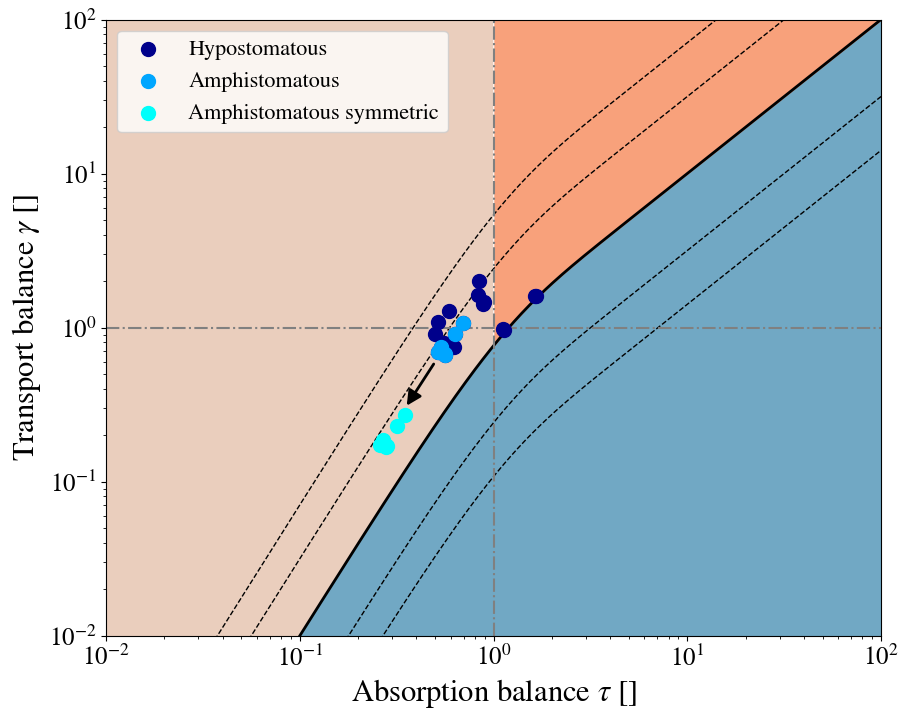

In [3]:
# load data 
df = pd.read_csv(ROOT + 'data/saved_data/Knauer2022_hypostomatous.csv', sep=';', decimal=',')
df_ = pd.read_csv(ROOT + 'data/saved_data/Knauer2022_most_ias_limited.csv', sep=';', decimal=',')


fig, ax1 = plt.subplots(1, 1, figsize=(10, 8))

N = 400
chi_ = 0.1
vmin, vmax = 0.01, 100
taus = np.exp(np.linspace(np.log(vmin), np.log(vmax), N))
borders = lambda taus, sigma: sigma*taus*np.tanh(taus)

# shading
ax1.fill_between(taus, borders(taus, 1), vmin, color=colorI)
ax1.fill_between(taus[taus <= 1], vmax, borders(taus[taus <= 1], 1), color=colorII)
ax1.fill_between(taus[taus >= 1], vmax, borders(taus[taus >= 1], 1), color=colorIII)
# lines
ax1.plot(taus, borders(taus, 1), color='black', linestyle='-', linewidth=2)
ax1.plot(taus, borders(taus, np.sqrt(50)), color='black', linestyle='--', linewidth=1)
ax1.plot(taus, borders(taus, np.sqrt(10)), color='black', linestyle='--', linewidth=1)
ax1.plot(taus, borders(taus, 1/np.sqrt(10)), color='black', linestyle='--', linewidth=1)
ax1.plot(taus, borders(taus, 1/np.sqrt(50)), color='black', linestyle='--', linewidth=1)

# plot the data 
labels = [r"Hypostomatous", r"Amphistomatous", r"Amphistomatous symmetric"]
colors = ["darkblue", "#00A6FF", "#00FFFB"]

mask = df_['hypostomatous'] != 'yes'
df_amphi = df_[mask]
df_amphi_sym = df_amphi.copy()
df_amphi_sym['tau'] = df_amphi_sym['tau'] / 2
df_amphi_sym['gamma'] = df_amphi_sym['gamma'] / 4

std_layout(ax1, [df_, df_amphi, df_amphi_sym], labels, colors=colors, markersize=100)
ax1.annotate('', xy=(0.35,0.3), xytext=(0.5, 0.6), arrowprops=dict(arrowstyle='-|>', color='black', linewidth=2))

plt.savefig(ROOT + "figures/vectorgraphics/supplementary/figure_amphi.svg")
plt.savefig(ROOT + "figures/vectorgraphics/supplementary/figure_amphi.png", dpi=300, bbox_inches='tight')
plt.show()


### Figure SX - underestimates of stomatal conductance $g_s$

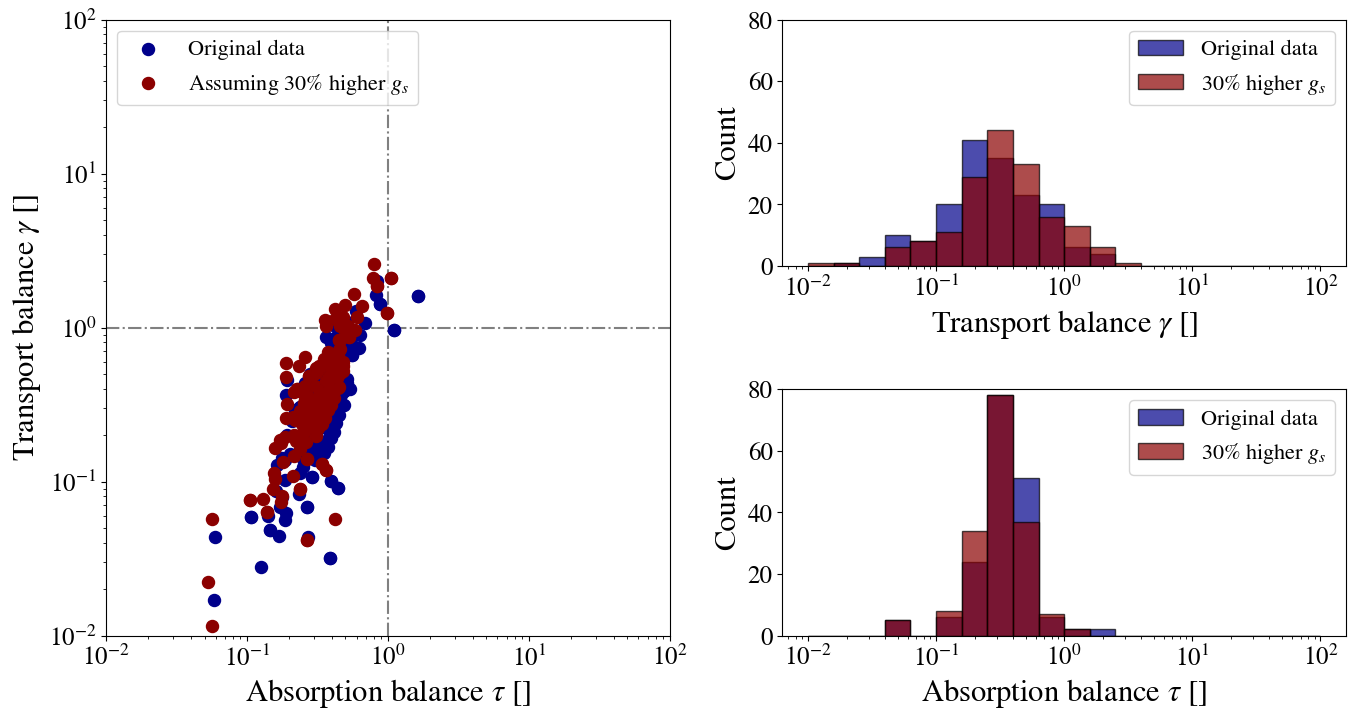

In [4]:
from python_module.functionality import numpy_estimate_parameters
np.random.seed(142)  # for reproducibility

# load data
df = pd.read_csv(ROOT + "data/saved_data/Knauer2022_pre_tau_gamma.csv", decimal=',', sep=';')
gs = df["stomatal_conductance"].to_numpy()
gias = df["ias_conductance"].to_numpy()
gm = df["mesophyll_conductance*"].to_numpy()
An = df["An"].to_numpy() 
Ci = df["substomatal_conc"].to_numpy()
C_ = df["compensation_point"].to_numpy() 
Ca = df["Ca_gas_exchange"].to_numpy()


# original values
taus, gammas = numpy_estimate_parameters(gm, gs, gias)
df = pd.DataFrame({"tau": taus, "gamma": gammas})

# now assume gs to be 30% higher than it is, then probagate to Ci and gm
factor = 0.30
gs_new = (1 + factor) * gs 
Ci_new = Ca - An / gs_new
gm_new = An / (Ci_new - C_)

taus_new, gammas_new = numpy_estimate_parameters(gm_new, gs_new, gias)
df_new = pd.DataFrame({"tau": taus_new, "gamma": gammas_new})

fig = plt.figure(figsize=(16, 8))
spec = fig.add_gridspec(2, 2, hspace=0.5)
ax_main = fig.add_subplot(spec[:, 0])
ax_hist_tau = fig.add_subplot(spec[1, 1])
ax_hist_gamma = fig.add_subplot(spec[0, 1])

std_layout(ax_main, [df, df_new], [r"Original data", r"Assuming 30% higher $g_s$"])

bins = np.logspace(-2, 2, 21)
alpha = 0.7

ax_hist_tau.hist(taus, bins=bins, alpha=alpha, color="darkblue", edgecolor="black", label="Original data")
ax_hist_tau.hist(taus_new, bins=bins, alpha=alpha, color="darkred", edgecolor="black", label=r"30% higher $g_s$")
ax_hist_tau.set_ylim(0, 80)
std_histogram(ax_hist_tau, xlabel="tau")

ax_hist_gamma.hist(gammas, bins=bins, alpha=alpha, color="darkblue", edgecolor="black", label="Original data")
ax_hist_gamma.hist(gammas_new, bins=bins, alpha=alpha, color="darkred", edgecolor="black", label=r"30% higher $g_s$")
ax_hist_gamma.set_ylim(0, 80)
std_histogram(ax_hist_gamma, xlabel="gamma")

plt.savefig(ROOT + "figures/vectorgraphics/supplementary/figure_saturation.svg")
plt.savefig(ROOT + "figures/vectorgraphics/supplementary/figure_saturation.png", dpi=300, bbox_inches='tight')
plt.show()


### Figure SX - uncertainty in estimates of IAS diffusivity of $CO_2$

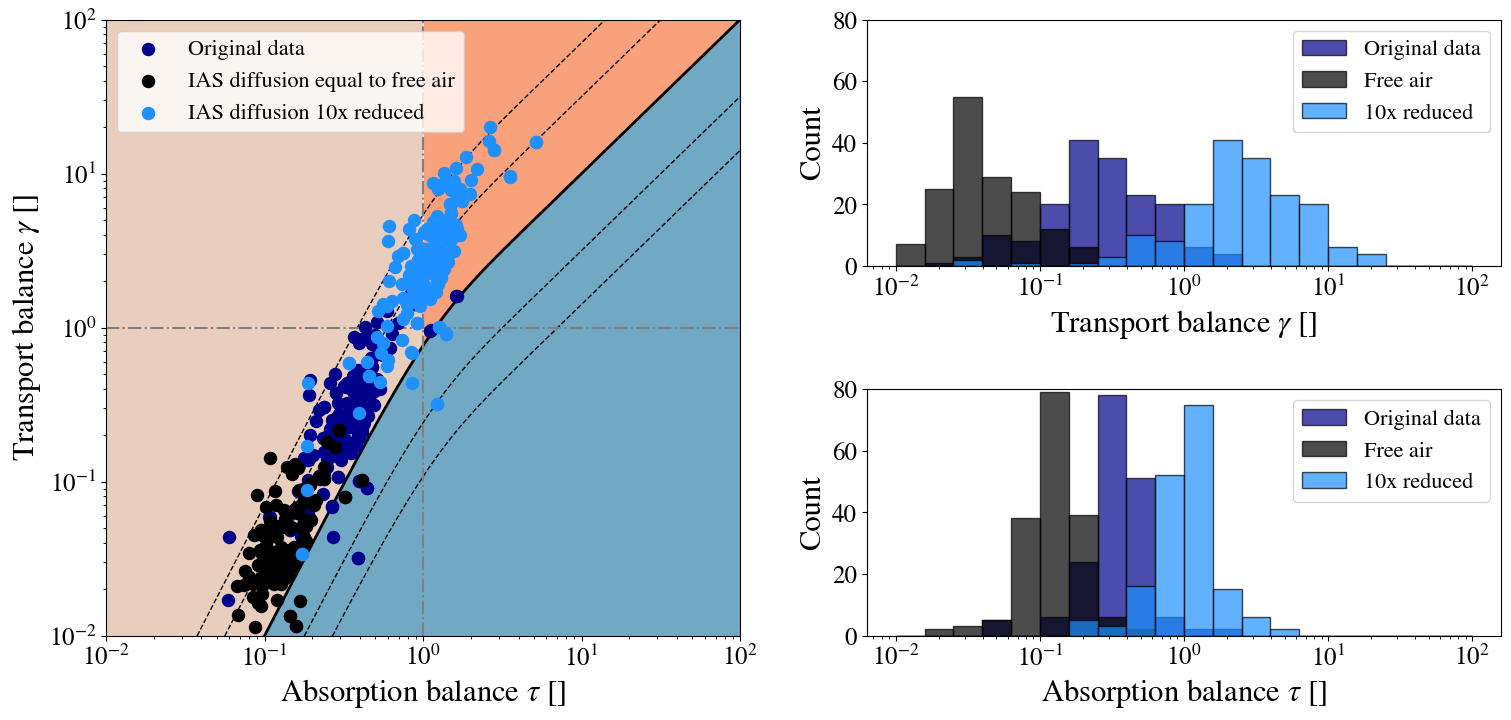

In [5]:
# load data
df = pd.read_csv(ROOT + "data/saved_data/Knauer2022_hypostomatous.csv", sep=';', decimal=',')


N = 400
chi_ = 0.1
vmin, vmax = 0.01, 100
taus = np.exp(np.linspace(np.log(vmin), np.log(vmax), N))
borders = lambda taus, sigma: sigma*taus*np.tanh(taus)



fig = plt.figure(figsize=(18, 8))
spec = fig.add_gridspec(2, 2, hspace=0.5)
ax = fig.add_subplot(spec[:, 0])
ax_hist_tau = fig.add_subplot(spec[1, 1])
ax_hist_gamma = fig.add_subplot(spec[0, 1])

# shading
ax.fill_between(taus, borders(taus, 1), vmin, color=colorI)
ax.fill_between(taus[taus <= 1], vmax, borders(taus[taus <= 1], 1), color=colorII)
ax.fill_between(taus[taus >= 1], vmax, borders(taus[taus >= 1], 1), color=colorIII)
# lines
ax.plot(taus, borders(taus, 1), color='black', linestyle='-', linewidth=2)
ax.plot(taus, borders(taus, np.sqrt(50)), color='black', linestyle='--', linewidth=1)
ax.plot(taus, borders(taus, np.sqrt(10)), color='black', linestyle='--', linewidth=1)
ax.plot(taus, borders(taus, 1/np.sqrt(10)), color='black', linestyle='--', linewidth=1)
ax.plot(taus, borders(taus, 1/np.sqrt(50)), color='black', linestyle='--', linewidth=1)
#
taus, gammas = df['tau'].to_numpy(), df['gamma'].to_numpy()


def scale(taus, gammas, factors):
    ''' 
    Function that scales the taus and gammas by a factor assuming that the geometry factor (porosity/tortuosity) is modified by the same factor.
    taus: np.ndarray of taus
    gammas: np.ndarray of gammas
    factors: np.ndarray of factors to scale the taus and gammas by
    Returns: scaled taus and gammas
    '''
    return taus / np.sqrt(factors), gammas / factors

# plot the case where there is no reduction from regular air diffusion at all
factors = np.zeros_like(taus)
for i in df.index.tolist():
    # cancel the geometry factor applied to the diffusivity in air (datareader_Knauer2022.ipynb)
    factors[i] = 1.57 / df.loc[i, 'fias_mesophyll'] # tortuosity adopted uniformly from Syvertsen et al 1995 (often in the range 1.4-1.6)

taus_as_air, gammas_as_air = scale(taus, gammas, factors)
df_as_air = pd.DataFrame({"tau": taus_as_air, "gamma": gammas_as_air})

# plot a factor 10 larger geometry factor
factors = 0.1*np.ones_like(taus)
taus_10x_lower, gammas_10x_lower = scale(taus, gammas, factors)
df_10x_lower = pd.DataFrame({"tau": taus_10x_lower, "gamma": gammas_10x_lower})

dfs = [df, df_as_air, df_10x_lower]
labels = [r"Original data", r"IAS diffusion equal to free air", r"IAS diffusion 10x reduced"]
colors = ["darkblue", "black", "dodgerblue"]

std_layout(ax, dfs, labels, colors=colors)

# histograms

bins = np.logspace(-2, 2, 21)
alpha = 0.7
ax_hist_tau.hist(taus, bins=bins, alpha=alpha, color="darkblue", edgecolor="black", label="Original data")
ax_hist_tau.hist(taus_as_air, bins=bins, alpha=alpha, color="black", edgecolor="black", label="Free air")
ax_hist_tau.hist(taus_10x_lower, bins=bins, alpha=alpha, color="dodgerblue", edgecolor="black", label="10x reduced")
ax_hist_tau.set_ylim(0, 80)
std_histogram(ax_hist_tau, xlabel="tau")

ax_hist_gamma.hist(gammas, bins=bins, alpha=alpha, color="darkblue", edgecolor="black", label="Original data")
ax_hist_gamma.hist(gammas_as_air, bins=bins, alpha=alpha, color="black", edgecolor="black", label="Free air")
ax_hist_gamma.hist(gammas_10x_lower, bins=bins, alpha=alpha, color="dodgerblue", edgecolor="black", label="10x reduced")
ax_hist_gamma.set_ylim(0, 80)
std_histogram(ax_hist_gamma, xlabel="gamma")   



plt.savefig(ROOT + "figures/vectorgraphics/supplementary/figure_geo.svg")
plt.savefig(ROOT + "figures/vectorgraphics/supplementary/figure_geo.png", dpi=300, bbox_inches='tight')
plt.show()


### Figure SX - bias in apparent stomatal and intracellular limitations

F-statistic: 3.236, p-value: 2.220e-16


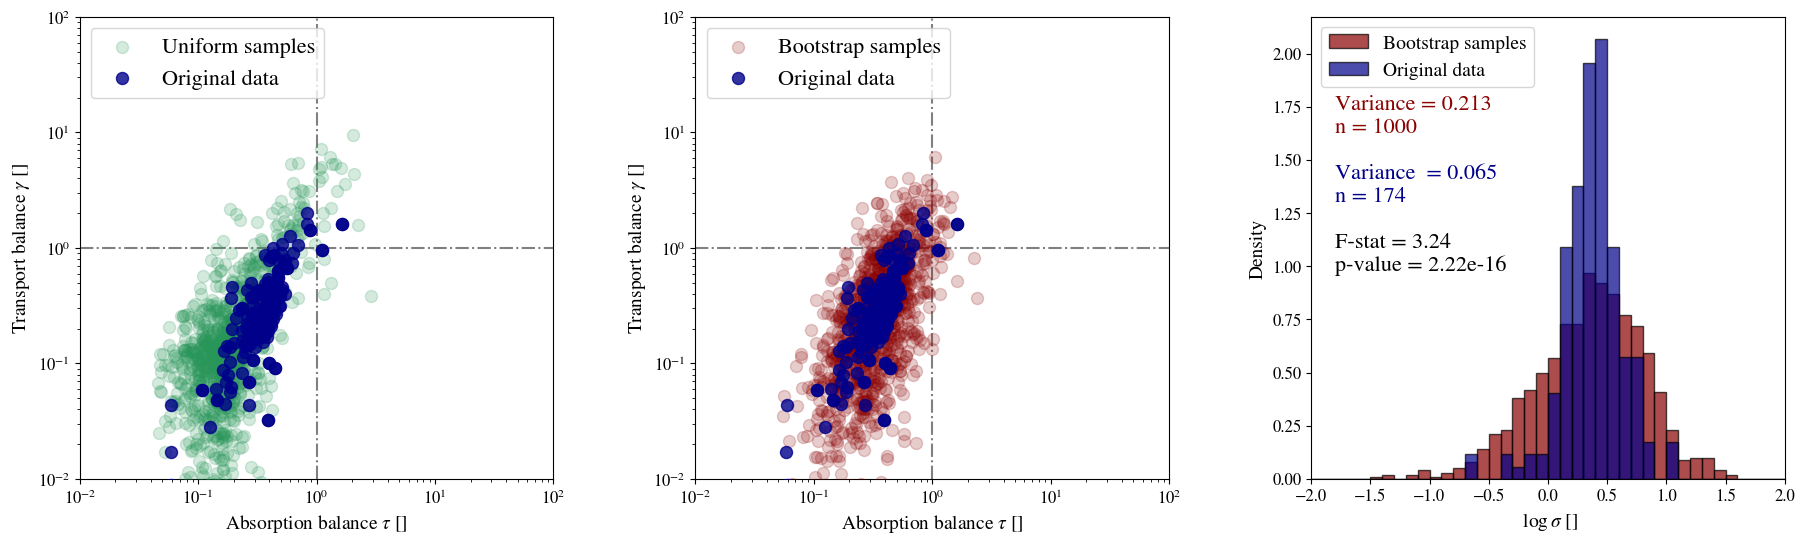

In [ ]:
from python_module.functionality import numpy_estimate_parameters
np.random.seed(142)  # for reproducibility

# load data
df = pd.read_csv(ROOT + "data/saved_data/Knauer2022_pre_tau_gamma.csv", decimal=',', sep=';')
gs = df["stomatal_conductance"].to_numpy()
L = df["mesophyll_thickness"].to_numpy()
Dias = df["ias_conductance"].to_numpy() * L
gias = Dias / L
gm = df["mesophyll_conductance*"].to_numpy()

def get_log_sigmas(taus: np.ndarray, gammas: np.ndarray) -> np.ndarray:
    return np.log10((gammas / (taus * np.tanh(taus))))

taus, gammas = numpy_estimate_parameters(gm, gs, gias)
log_sigmas = get_log_sigmas(taus, gammas)
df = pd.DataFrame({"tau": taus, "gamma": gammas, "log_sigma": log_sigmas})

num_samples = 1_000 

# uniform sampling definition
def uniform_sample(data, size):
    return np.random.uniform(low=np.min(data), high=np.max(data), size=size)
# sample parameters
gs_uniform = uniform_sample(gs, num_samples)
gias_uniform = uniform_sample(gias, num_samples)
gm_uniform = uniform_sample(gm, num_samples)
# calculate tau, gamma, sigma
taus_uniform, gammas_uniform = numpy_estimate_parameters(gm_uniform, gs_uniform, gias_uniform)
log_sigmas_uniform = get_log_sigmas(taus_uniform, gammas_uniform)
df_uniform = pd.DataFrame({"tau": taus_uniform, "gamma": gammas_uniform, "log_sigma": log_sigmas_uniform})


# bootstrap sampling definition
def bootstrap_sample(data, size):
    return np.random.choice(data, size=size, replace=True)     
# sample parameters
gs_boot = bootstrap_sample(gs, num_samples)
L_boot = bootstrap_sample(L, num_samples)
Dias_boot = bootstrap_sample(Dias, num_samples)
gias_boot = Dias_boot / L_boot
gm_boot = bootstrap_sample(gm, num_samples)
# calculate tau, gamma, sigma    
taus_boot, gammas_boot = numpy_estimate_parameters(gm_boot, gs_boot, gias_boot)
log_sigmas_boot = get_log_sigmas(taus_boot, gammas_boot)
df_boot = pd.DataFrame({"tau": taus_boot, "gamma": gammas_boot, "log_sigma": log_sigmas_boot})

figure, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6), gridspec_kw={"wspace": 0.3})

# uniform comparison
std_layout(ax1, [df_uniform, df], [r"Uniform samples", r"Original data"], colors=["#289659", "darkblue"], alphas=[0.2, 0.8])
# alpha 0.05, 0.8


# bootstrap comparison
std_layout(ax2, [df_boot, df], [r"Bootstrap samples", r"Original data"], colors=["darkred", "darkblue"], alphas=[0.2, 0.8])


# binning sigma histogram

bins = np.linspace(-2, 2, 41)

ax3.hist(log_sigmas_boot, bins=bins, alpha=0.7, edgecolor="black", label="Bootstrap samples", color="darkred", density=True)
ax3.hist(log_sigmas,         bins=bins, alpha=0.7, edgecolor="black", label="Original data", color="darkblue", density=True)
ax3.set_ylabel('Density')
ax3.set_xlabel(r" $\log \sigma$ []")
ax3.set_xlim(-2, 2)

# calculate p-value for the null hypothesis that the bootstrap distribution has the same variance as the original distribution
from scipy.stats import f 

var_original = np.var(log_sigmas, ddof=1)
var_bootstrap = np.var(log_sigmas_boot, ddof=1)

dof_original = len(log_sigmas) - 1
dof_bootstrap = len(log_sigmas_boot) - 1

F = var_bootstrap / var_original

cdf_value = f.cdf(F, dof_bootstrap, dof_original)
pvalue = 2 * min(cdf_value, 1 - cdf_value)
pvalue = min(pvalue, 1.0)

print(f"F-statistic: {F:.3f}, p-value: {pvalue:.3e}")


# annotate variances of the two distributions
var_original = np.var(log_sigmas)
var_bootstrap = np.var(log_sigmas_boot)
ax3.text(-1.8, 0.80 * ax3.get_ylim()[1], f"Variance = {var_bootstrap:.3f}", color="darkred", fontsize=16)
ax3.text(-1.8, 0.75 * ax3.get_ylim()[1], f"n = {num_samples}", color="darkred", fontsize=16)
ax3.text(-1.8, 0.65 * ax3.get_ylim()[1], f"Variance  = {var_original:.3f}", color="darkblue", fontsize=16)
ax3.text(-1.8, 0.60 * ax3.get_ylim()[1], f"n = {len(log_sigmas)}", color="darkblue", fontsize=16)
ax3.text(-1.8, 0.50 * ax3.get_ylim()[1], f"F-stat = {F:.2f}", color="black", fontsize=16)
ax3.text(-1.8, 0.45 * ax3.get_ylim()[1], f"p-value = {pvalue:.2e}", color="black", fontsize=16)
ax3.legend(fontsize=14)

plt.savefig(ROOT + "figures/vectorgraphics/supplementary/figure_bias.svg")
plt.savefig(ROOT + "figures/vectorgraphics/supplementary/figure_bias.png", dpi=300, bbox_inches='tight')
plt.show()


### Figure SX - Saturating Rubisco kinetics

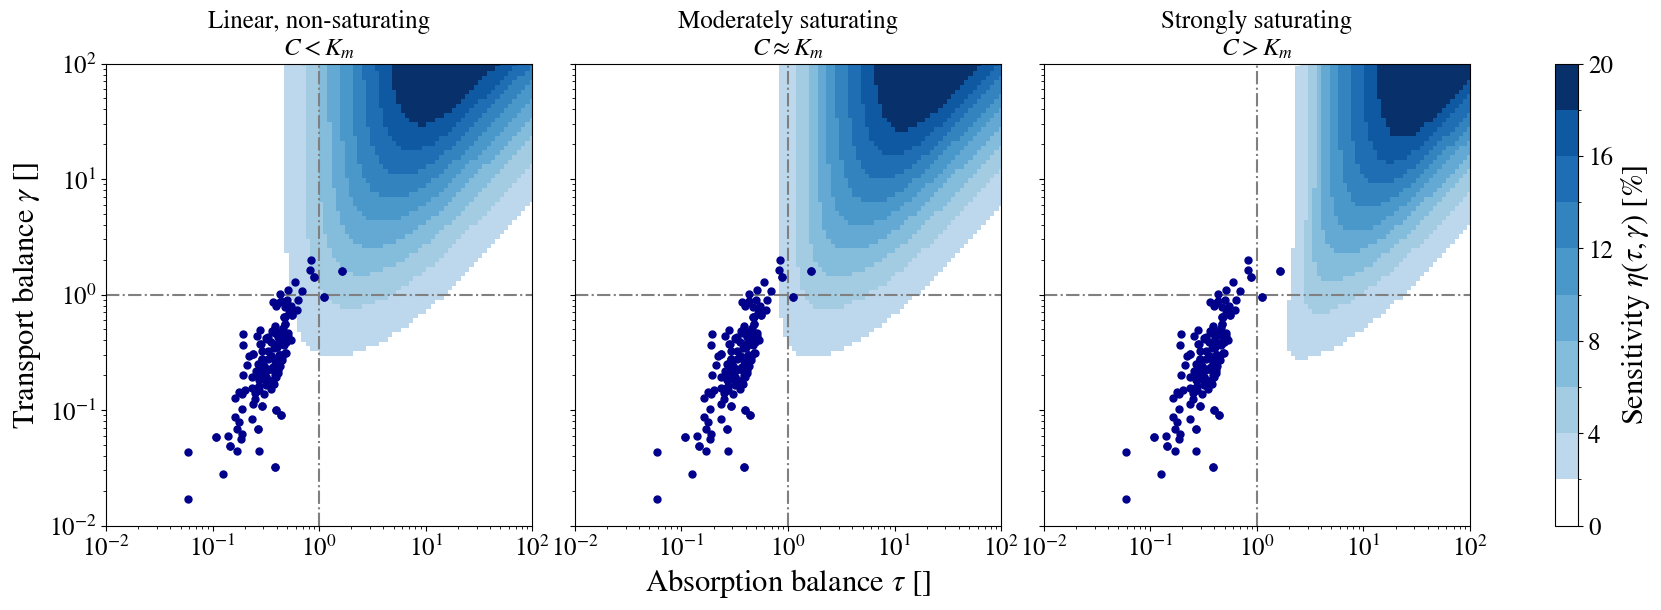

In [7]:

# load data
dfKnauer = pd.read_csv(ROOT + "data/saved_data/Knauer2022_hypostomatous.csv", sep=';', decimal=',')


sensitivity0_00 = 100*np.loadtxt(ROOT + "supplementary/files/nonlinear_sensitivities/sensitivities_mu0.00_.txt", delimiter=";").T
sensitivity1_00 = 100*np.loadtxt(ROOT + "supplementary/files/nonlinear_sensitivities/sensitivities_mu1.00_.txt", delimiter=";").T
sensitivity8_00 = 100*np.loadtxt(ROOT + "supplementary/files/nonlinear_sensitivities/sensitivities_mu8.00_.txt", delimiter=";").T
sensitivities = [sensitivity0_00, sensitivity1_00, sensitivity8_00]
titles = ["Linear, non-saturating\n"+r"$C < K_m$", "Moderately saturating\n"+r"$C \approx K_m$", "Strongly saturating\n"+r"$C > K_m$"]

fig, axs = plt.subplots(1, 3, figsize=(22, 6), sharey=True, gridspec_kw={"wspace": 0.1})

axs = axs.flatten()
for ax, sensitivity, title in zip(axs, sensitivities, titles):
    im = plot_heat_map(ax, sensitivity, title)
    ax.scatter(df['tau'], df['gamma'], color="darkblue", marker="o", zorder=3, s=25)

cbar = plt.colorbar(im, ax=axs, orientation="vertical")
cbar.set_label(r"Sensitivity $\eta(\tau, \gamma)$ [%]")
axs[0].set_ylabel(r"Transport balance $\gamma$ []")
axs[1].set_xlabel(r"Absorption balance $\tau$ []")


plt.savefig(ROOT + "figures/vectorgraphics/supplementary/figure_nonlinear.svg")
plt.savefig(ROOT + "figures/vectorgraphics/supplementary/figure_nonlinear.png", dpi=300, bbox_inches='tight')
plt.show()

### Figure SX - Sensitivity to heterogeneity as function of contrast

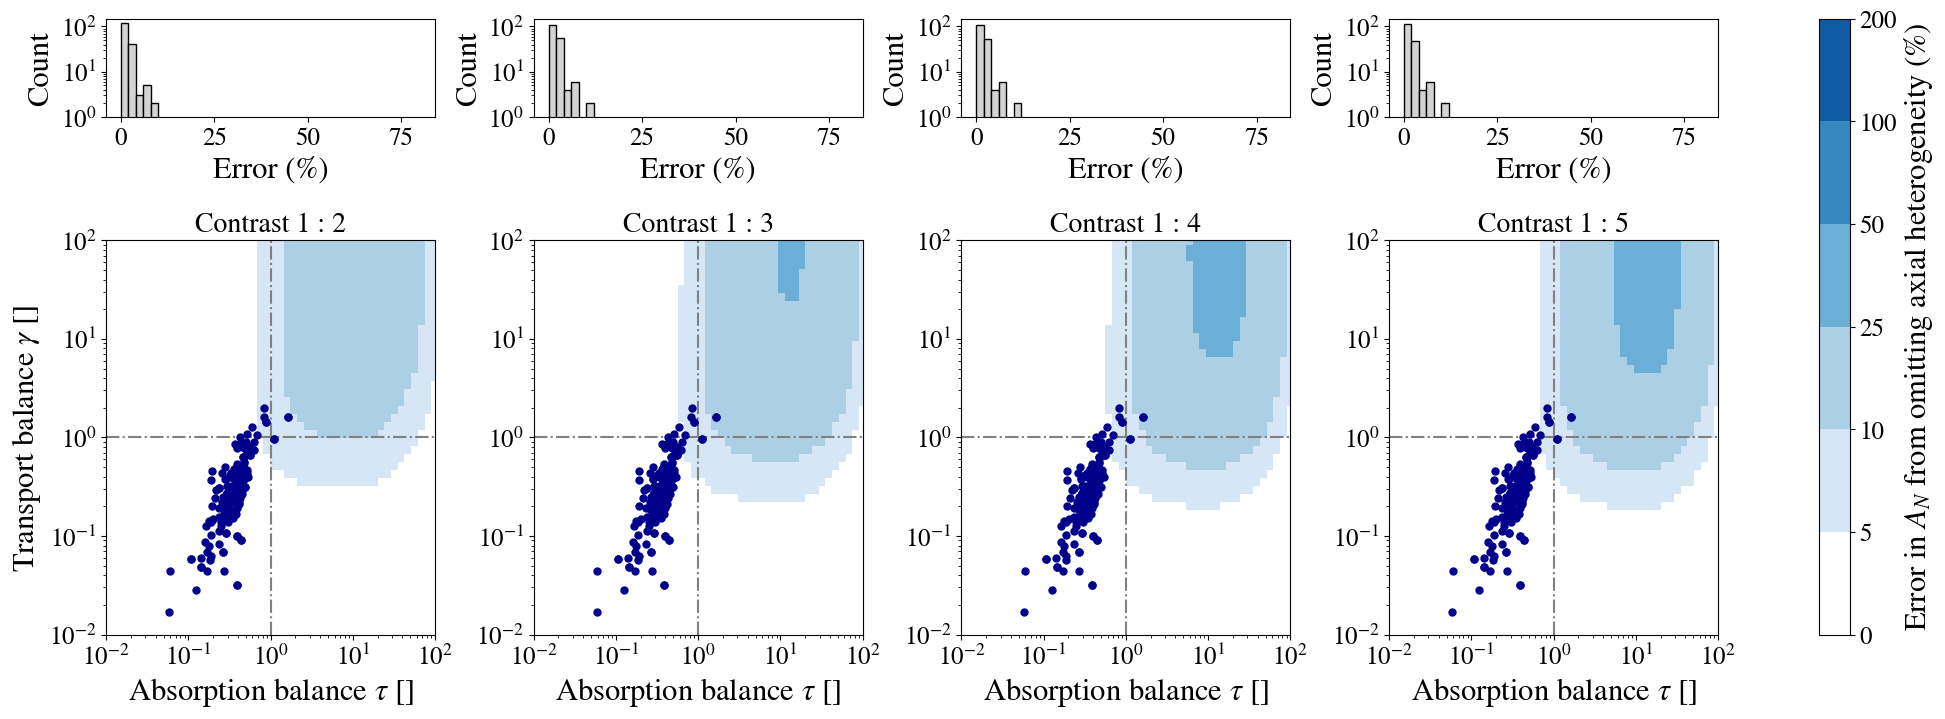

In [8]:

# load data
dfKnauer = pd.read_csv(ROOT + "data/saved_data/Knauer2022_hypostomatous.csv", sep=';', decimal=',')

error2 = 100 * np.loadtxt(ROOT + "data/saved_data/heatmaps/heterogeneity/3D_typical_contrast_0.50.txt", delimiter=";").T
error3 = 100 * np.loadtxt(ROOT + "data/saved_data/heatmaps/heterogeneity/3D_typical_contrast_0.33.txt", delimiter=";").T
error4 = 100 * np.loadtxt(ROOT + "data/saved_data/heatmaps/heterogeneity/3D_typical_contrast_0.25.txt", delimiter=";").T
error5 = 100 * np.loadtxt(ROOT + "data/saved_data/heatmaps/heterogeneity/3D_typical_contrast_0.20.txt", delimiter=";").T

error2_data = map_data_values(df, error2)
error3_data = map_data_values(df, error3)
error4_data = map_data_values(df, error4)
error5_data = map_data_values(df, error5)

def error_histogram(ax: plt.Axes, errors: np.ndarray) -> None:
    ax.set_ylabel("Count")
    ax.set_xlabel("Error (%)")
    ax.set_yscale("log")
    ax.set_ylim(1, 150)
    return

errors = [error2, error3, error4, error5]
errors_data = [error2_data, error3_data, error4_data, error5_data]
titles = ["Contrast 1 : 2", "Contrast 1 : 3", "Contrast 1 : 4", "Contrast 1 : 5"]


def make_colormap(basis: str, bounds: list) -> tuple[ListedColormap, BoundaryNorm]:
    cmap = plt.get_cmap(basis, len(bounds))
    colors = cmap(range(len(bounds)-1))
    colors[0] = (1, 1, 1, 1)  # set the first color to white
    cmap = ListedColormap(colors)
    norm = BoundaryNorm(bounds, cmap.N)
    return cmap, norm 

vmin, vmax = 0.01, 100
cmap, norm = make_colormap('Blues', bounds=[0, 5, 10, 25, 50, 100, 200])


# fig, axs = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
fig, axs_all = plt.subplots(2, 4, gridspec_kw={"height_ratios": [1, 4], "hspace": 0.5, "wspace": 0.3},
                        figsize=(26, 8))
axs_hist = axs_all[0,:].flatten()
axs = axs_all[1,:].flatten()


for ax, error, title in zip(axs, errors, titles):
    N = len(error)
    taus = np.exp(np.linspace(np.log(vmin), np.log(vmax), N))
    gammas = np.exp(np.linspace(np.log(vmin), np.log(vmax), N))
    # layout
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(vmin, vmax)
    ax.set_ylim(vmin, vmax)
    ax.plot([1, 1], [vmin, vmax], color="grey", linestyle="-.", zorder=2)
    ax.plot([vmin, vmax], [1, 1], color="grey", linestyle="-.", zorder=2)
    ax.set_title(title)
    im = ax.pcolor(taus, gammas, error, shading="nearest", cmap=cmap, norm=norm)
    ax.scatter(df['tau'], df['gamma'], color="darkblue", marker="o", zorder=3, s=25)

bins = np.linspace(0, 80, 41)
for ax, error_data in zip(axs_hist, errors_data):
    ax.hist(error_data, bins=bins, edgecolor="black", color="lightgrey")
    error_histogram(ax, error_data)

fig.colorbar(im, ax=axs_all, orientation="vertical", label=r"Error in $A_N$ from omitting axial heterogeneity (%)")
axs[0].set_ylabel(r"Transport balance $\gamma$ []")
axs[0].set_xlabel(r"Absorption balance $\tau$ []")
axs[1].set_xlabel(r"Absorption balance $\tau$ []")
axs[2].set_xlabel(r"Absorption balance $\tau$ []")
axs[3].set_xlabel(r"Absorption balance $\tau$ []")


plt.savefig(ROOT + "figures/vectorgraphics/supplementary/figure_contrast.svg")
plt.savefig(ROOT + "figures/vectorgraphics/supplementary/figure_contrast.png", dpi=300, bbox_inches='tight')
plt.show()


### Figure SX - Non-steady state conditions

/home/andreasstillits/coding/Leaves1D/supplementary


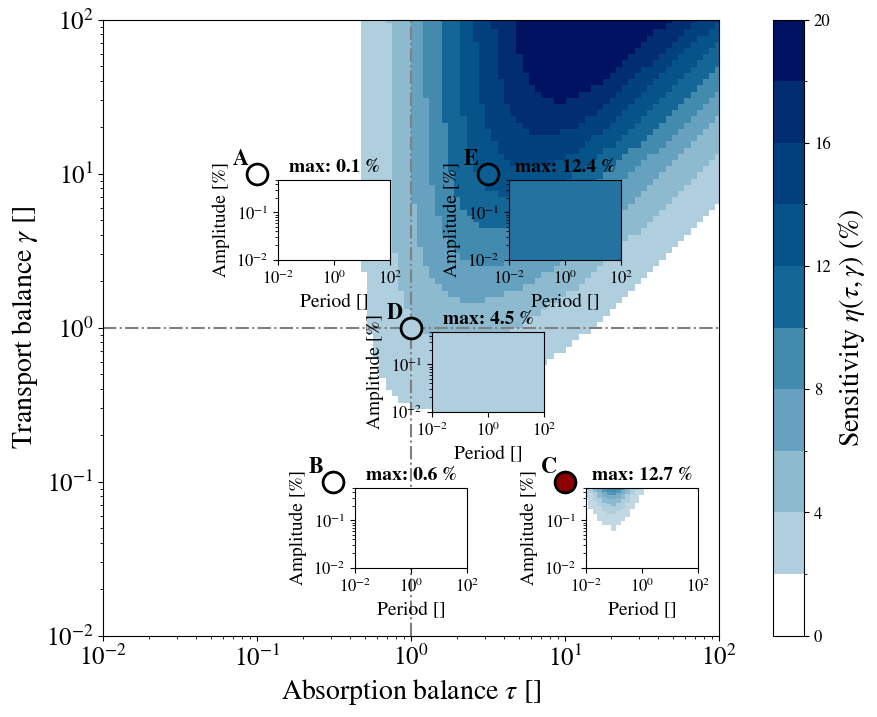

In [9]:
df = pd.read_csv(ROOT + "data/saved_data/Knauer2022_hypostomatous.csv", sep=';', decimal=',')

PATH = ROOT + "supplementary/"
%cd $PATH

from codebase.utils.plotfunctions import plot_sensitivity_map , plot_temporal_scan, get_blue_cmap
from codebase.utils.constants import Cases

fig, ax = plt.subplots(figsize=(14, 8))
im = plot_sensitivity_map(ROOT + "supplementary/files/nonlinear_sensitivities/sensitivities_mu0.00_.txt", bounds=(0, 20, 11), ax=ax)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r'Sensitivity $\eta(\tau, \gamma)$ (%)', fontsize=20)
# ax.scatter(df['tau'], df['gamma'], color="#3493F9", marker="o", zorder=2, s=25, alpha=1)
ax.set_xlabel(r'Absorption balance $\tau$ []', fontsize=20)
ax.set_ylabel(r'Transport balance $\gamma$ []', fontsize=20)
# ax.set_title("Time Dependent Sensitivity Analysis", fontsize=20)
# place circles for cases A - E
cases = Cases()
labels = ["A", "B", "C", "D", "E"]
circles = []
for label in labels:
    tau, gamma, chi_ = cases.get_case_params(label)
    circles.append((tau, gamma))
# plot circles
cmap, norm = get_blue_cmap((0, 20, 12))
colors = ['white', 'white', 'darkred', cmap(norm(3)), cmap(norm(12))]
for label, color, (tau, gamma) in zip(labels, colors, circles):
    ax.plot(tau, gamma, marker='o', markersize=15, markeredgecolor='black', markeredgewidth=2, markerfacecolor=color)
    ax.text(tau*0.70, gamma*1.15, label, color='black', fontsize=16, fontweight='bold')

# make inset plots
def _make_inset(case: str, rect: list[float], rhomax: float = 0.3) -> None:
    inset_ax = fig.add_axes(rect)
    max_sens = plot_temporal_scan("gs", case, rhomax, ax=inset_ax)
    inset_ax.set_title(f"max: {100*max_sens:.1f} %", fontsize=14, fontweight='bold')
    inset_ax.set_xlabel("Period []", fontsize=14)
    inset_ax.set_ylabel("Amplitude [%]", fontsize=14)
    
_make_inset("A", [0.430, 0.580, 0.08, 0.1])
_make_inset("B", [0.485, 0.195, 0.08, 0.1])
_make_inset("C", [0.650, 0.195, 0.08, 0.1])
_make_inset("D", [0.540, 0.390, 0.08, 0.1])
_make_inset("E", [0.595, 0.580, 0.08, 0.1])

plt.savefig(ROOT + "figures/vectorgraphics/supplementary/figure_osc.svg")
plt.savefig(ROOT + "figures/vectorgraphics/supplementary/figure_osc.png", dpi=300, bbox_inches='tight')
plt.show()

